# 05 — Production-side view: sectoral GVA
Notebooks 02-03 looked at GDP from the demand/expenditure side. This notebook adds the **production side**: Gross Value Added decomposed into the three headline sectors the review asked for —

- **Agriculture** — Agriculture, Forestry & Fishing
- **Industry** — Mining + Manufacturing + Utilities + Construction
- **Services** — Trade/Transport/Comm + Financial & Real Estate + Public Admin

Source: RBI DBIE, *Quarterly Estimates of GVA at Basic Prices (Constant Prices), New Series (Base 2011-12)*. Because this is the 2011-12 base series (through Sep 2025), it aligns with the old-base portion of the modelling panel — the same splice caveat noted for GDP applies here. GVA is **structural context**, not a forecast input.

In [ ]:
import sys, os
from pathlib import Path
from IPython.display import Image, display
PROJECT = Path(os.environ.get("GDP_PROJECT", "")).expanduser()
if not (PROJECT / "data").is_dir():
    here = Path.cwd()
    for cand in (here, *here.parents):
        if (cand / "data" / "processed").is_dir():
            PROJECT = cand; break
sys.path.insert(0, str(PROJECT / "src"))
import gva_sectors
# project resolved automatically

In [ ]:
# Regenerates figures 05a/05b/05c and the tidy CSV from the raw DBIE export,
# folding the 8 sub-sectors into Agriculture / Industry / Services.
tidy = gva_sectors.build(PROJECT)
FIGS = PROJECT / "outputs" / "figures"
tidy[["FY_Quarter","Agriculture_YoY","Industry_YoY","Services_YoY","GVA_total_YoY"]].tail(8).round(2)

reading: gva_by_activity_quarterly.xlsx
  Agriculture  <- 1 column(s): ['1. Agriculture, Forestry and Fishin']
  Industry     <- 4 column(s): ['2. Mining & Quarrying', '3. Manufacturing', '4. Electricity, Gas, Water Supply &', '5. Construction']
  Services     <- 3 column(s): ['6. Trade, Hotels, Transport, Commun', '7. Financial, Real Estate and Profe', '8. Public Administration, Defence a']
saved figures 05a/05b/05c and gva_sectoral_quarterly.csv

Latest sector growth (YoY %):
FY_Quarter  Agriculture_YoY  Industry_YoY  Services_YoY  GVA_total_YoY
2024-25 Q1             1.46          8.45          6.78           6.55
2024-25 Q2             4.11          3.76          7.24           5.81
2024-25 Q3             6.64          4.85          7.38           6.49
2024-25 Q4             5.37          6.49          7.34           6.77
2025-26 Q1             3.73          6.30          9.28           7.63
2025-26 Q2             3.54          7.71          9.23           8.12


,FY_Quarter,Agriculture_YoY,Industry_YoY,Services_YoY,GVA_total_YoY
50,2023-24 Q3,1.46,11.83,8.28,8.00
51,2023-24 Q4,0.86,9.52,7.85,7.27
52,2024-25 Q1,1.46,8.45,6.78,6.55
53,2024-25 Q2,4.11,3.76,7.24,5.81
54,2024-25 Q3,6.64,4.85,7.38,6.49
55,2024-25 Q4,5.37,6.49,7.34,6.77
56,2025-26 Q1,3.73,6.30,9.28,7.63
57,2025-26 Q2,3.54,7.71,9.23,8.12


## 1 · Sectoral growth
YoY growth of each sector against total GVA. Services runs steady and high; Industry is more cyclical; Agriculture is the most volatile (weather-driven).

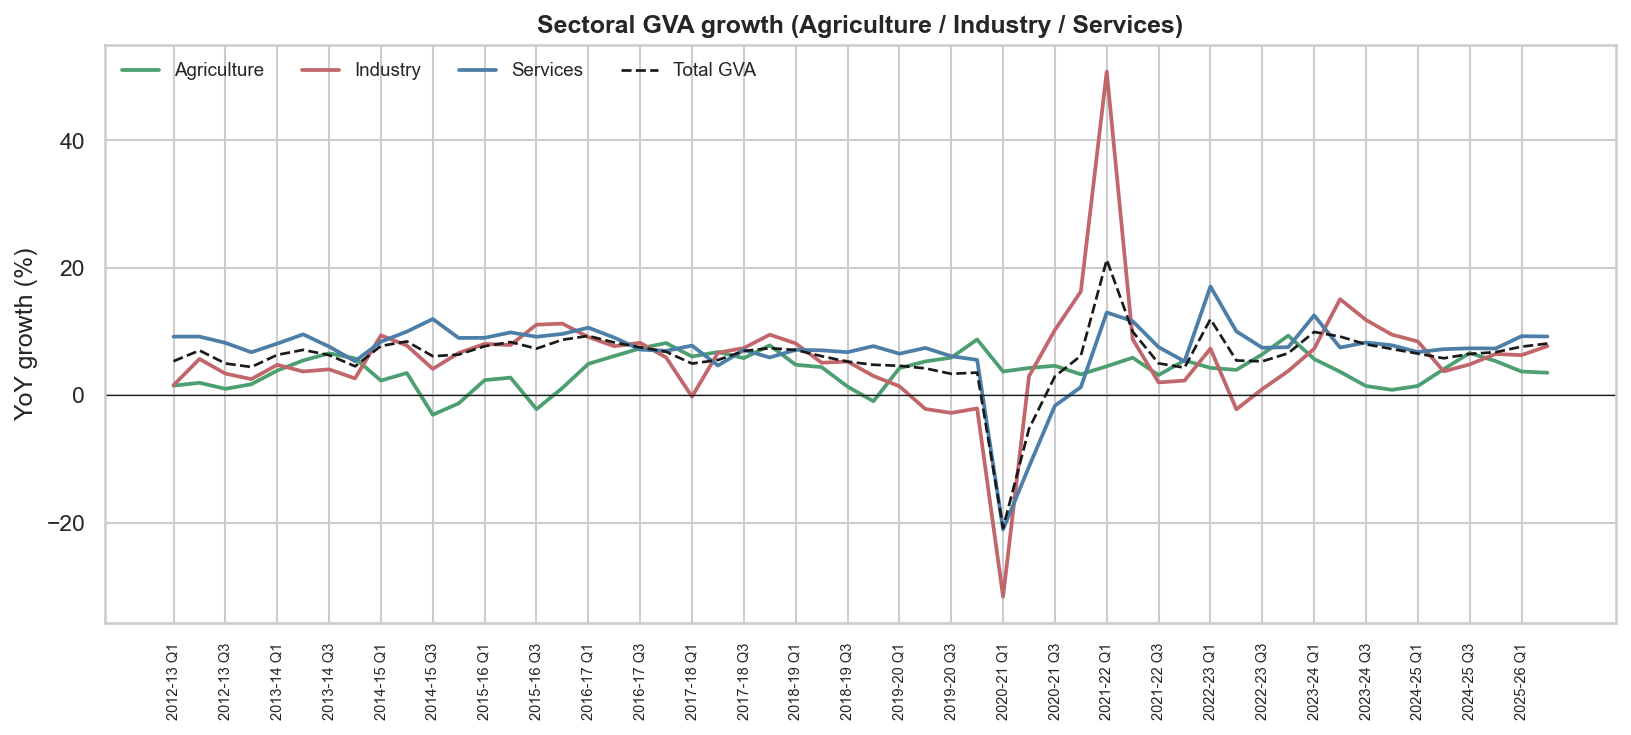

In [ ]:
display(Image(str(FIGS / '05a_gva_sector_growth.png')))

## 2 · Contribution to growth
Each quarter's GVA growth split into sector contributions (share x own-growth), mirroring the demand-side chart in notebook 03. Services carries the bulk of growth every quarter.

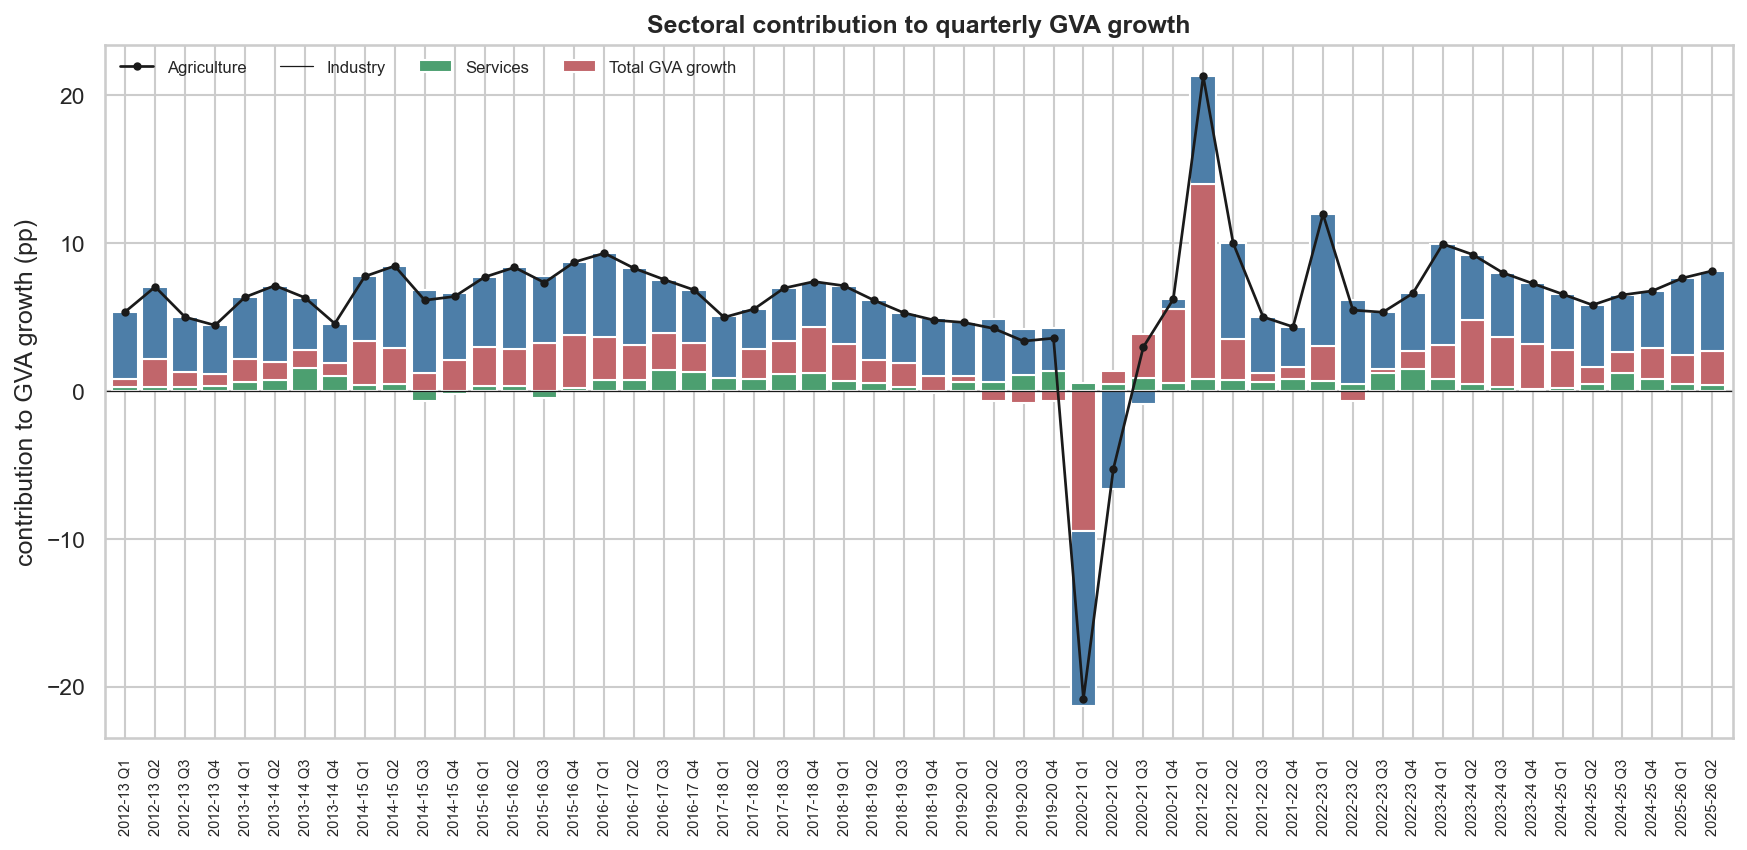

In [ ]:
display(Image(str(FIGS / '05b_gva_contributions.png')))

## 3 · Structural shares
Sector shares of GVA over FY13-FY26 — the rising Services share and slowly declining Agriculture share.

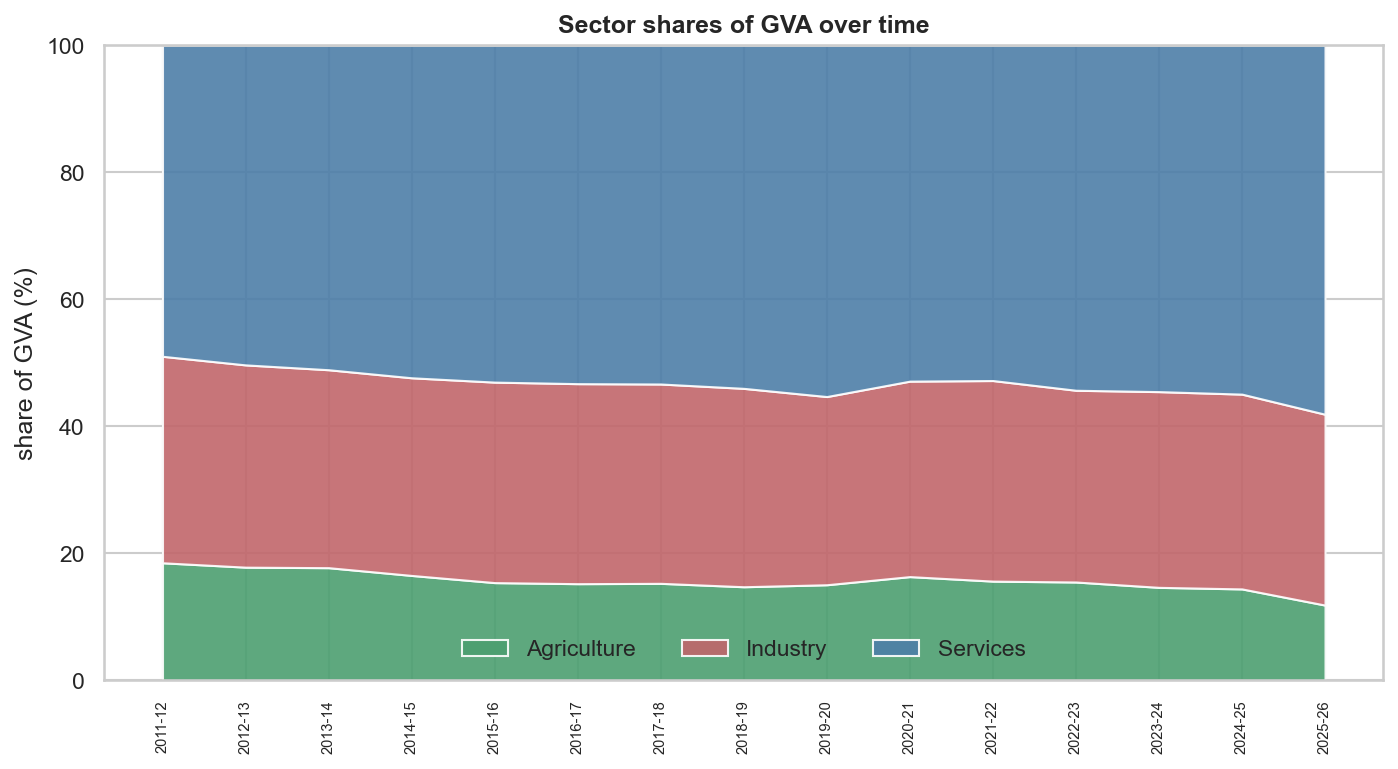

In [ ]:
display(Image(str(FIGS / '05c_gva_shares_annual.png')))

### Takeaway
Services is both the largest component of GVA and the dominant contributor to growth (≈9% YoY in early FY26); Industry a firm 6-8%; Agriculture volatile (3-7%). This production-side view complements the expenditure-side decomposition and shows **where** each quarter's growth originates — the question the review flagged as missing.